## Hidden Markov Model (HMM): Regime Detection

Markets are non-stationary, with changing volatility and dynamics over time.  
We use an HMM to model this via hidden regimes.

In this notebook:
- fit HMM on training data (time-series aware)
- infer regime labels and probabilities
- analyse behaviour across regimes

Goal: extract regime structure to improve the alpha model.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import glob
from microstructure_alpha.data.loader import load_parquet_glob
from microstructure_alpha.plots import plot_fold_aucs, plot_rolling_calibration
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import StandardScaler
import copy
from microstructure_alpha.features.feature_lists import (
    MID_PRICE_MOVE_FINAL,
    SIGN_MODEL_FEATURES,
)

In [2]:
final_dataset = load_parquet_glob(
    "C:\\Users\\jayod\\Documents\\Quant_Project\\microstructure-alpha-engine\\data\\ml_ready_data\\ml_ready.parquet",
    sort_by="timestamp",
)

In [3]:
splits = 10
tscv = TimeSeriesSplit(n_splits=splits, gap=50)

In [4]:
hmm_features = [
    # "log_return_1",
    "vol_5",
    "vol_20",
    # "spread",
    # "imbalance_1",
    # "trade_volume_imbalance",
]

In [5]:
X = final_dataset
X_hmm = final_dataset[hmm_features]

# Model

In [6]:
from hmmlearn.hmm import GaussianHMM

n_states = 2
hmm_model = GaussianHMM(
    n_components=n_states, covariance_type="diag", n_iter=200, tol=1e-3, random_state=42
)

In [7]:
all_regimes = np.zeros(len(X_hmm))
all_probs = np.zeros((len(X_hmm), n_states))  # assuming 3 states
clip_quantiles = (0.01, 0.99)

for fold, (train_idx, test_idx) in enumerate(tscv.split(X)):
    X_train = X_hmm.iloc[train_idx].copy()
    X_train = X_train.replace([np.inf, -np.inf], 0).fillna(0)
    X_test = X_hmm.iloc[test_idx].copy()

    X_train = X_train.replace([np.inf, -np.inf], 0).fillna(0)

    lower = X_train.quantile(clip_quantiles[0])
    upper = X_train.quantile(clip_quantiles[1])

    X_train = X_train.clip(lower, upper, axis=1)
    X_test = X_test.clip(lower, upper, axis=1)

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    X_train_scaled = pd.DataFrame(
        X_train_scaled, columns=X_train.columns, index=X_train.index
    )
    hmm_model = GaussianHMM(
        n_components=n_states,
        covariance_type="diag",
        n_iter=20000,
        tol=1e-3,
        random_state=42,
    )

    hmm_model.fit(X_train_scaled)

    trans = hmm_model.transmat_

    regimes = hmm_model.predict(X_test_scaled)
    probs = hmm_model.predict_proba(X_test_scaled)
    regimes_train = hmm_model.predict(X_train_scaled)
    X_train_scaled["regime"] = regimes_train

    print(f"\nFold {fold}")
    print(X_train_scaled.groupby("regime")[hmm_features].mean())

    all_regimes[test_idx] = regimes
    all_probs[test_idx] = probs

c:\Users\jayod\miniconda3\envs\microstructure-alpha-engine\Lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)



Fold 0
           vol_5    vol_20
regime                    
0      -0.438267 -0.512211
1       0.811804  0.948771

Fold 1
           vol_5    vol_20
regime                    
0      -0.432911 -0.525450
1       0.819855  0.995107

Fold 2
           vol_5    vol_20
regime                    
0       1.235565  1.434426
1      -0.379748 -0.440867

Fold 3
           vol_5    vol_20
regime                    
0      -0.563371 -0.651538
1       0.883225  1.021448

Fold 4
           vol_5    vol_20
regime                    
0       0.698121  0.826474
1      -0.654798 -0.775186

Fold 5
           vol_5    vol_20
regime                    
0       0.705456  0.837814
1      -0.623565 -0.740558

Fold 6
           vol_5    vol_20
regime                    
0       0.712484  0.844022
1      -0.610403 -0.723095

Fold 7
           vol_5    vol_20
regime                    
0       0.686273  0.817174
1      -0.624885 -0.744076

Fold 8
           vol_5    vol_20
regime                    
0      -0.

In [8]:
final_dataset["regime"] = all_regimes

final_dataset.groupby("regime")["vol_5"].agg(["mean", "std"])

,mean,std
regime,,
0.0,0.000068,0.000074
1.0,0.000077,0.000071


In [9]:
print(final_dataset.groupby("regime")["vol_5"].agg(["mean", "std"]))

            mean       std
regime                    
0.0     0.000068  0.000074
1.0     0.000077  0.000071


In [10]:
print((final_dataset["regime"].shift(1) == final_dataset["regime"]).mean())

0.9786131502988704


In [11]:
print(final_dataset["regime"].value_counts(normalize=True))

regime
0.0    0.631083
1.0    0.368917
Name: proportion, dtype: float64


In [12]:
final_dataset.groupby("regime")[hmm_features].mean()

,vol_5,vol_20
regime,,
0.0,0.000068,0.000082
1.0,0.000077,0.000093


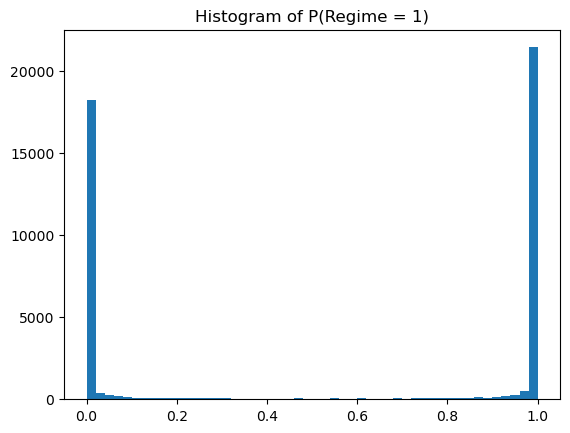

In [13]:
import matplotlib.pyplot as plt

# histogram for regime 1 probabilities
plt.hist(all_probs[:, 0], bins=50)
plt.title("Histogram of P(Regime = 1)")
plt.show()

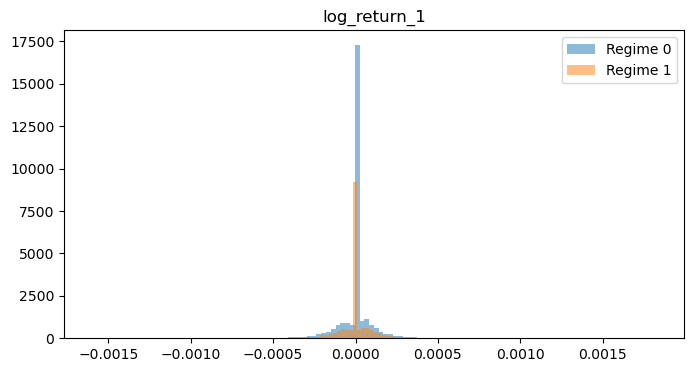

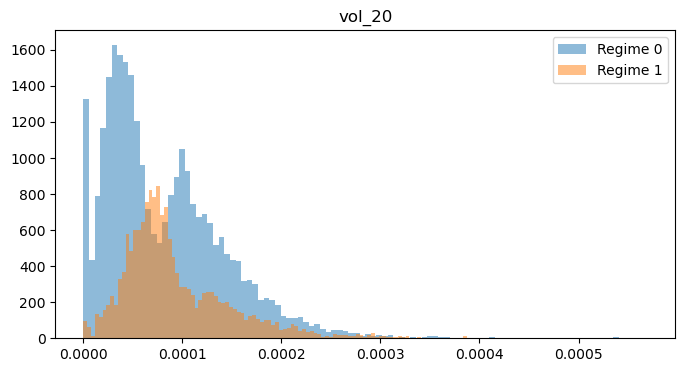

In [14]:
import matplotlib.pyplot as plt

for col in ["log_return_1", "vol_20"]:
    plt.figure(figsize=(8, 4))

    for k in range(n_states):
        data = final_dataset[final_dataset["regime"] == k][col]
        plt.hist(data, bins=100, alpha=0.5, label=f"Regime {k}")

    plt.title(col)
    plt.legend()
    plt.show()

In [15]:
final_dataset.groupby("regime").agg(
    {
        "vol_20": ["mean", "std"],
        "mid_price_change_1": ["std"],
    }
)

vol_20           mid_price_change_1
            mean       std                std
regime                                       
0.0     0.000082  0.000061           7.231923
1.0     0.000093  0.000055           7.725291